In [38]:
# PLAN

# Import data                   DONE
# Verify data integrity         DONE
# Split data train/test/[val]   DONE
# Data pre-processing:
#   * Image Normalisation       DONE
#   * Hand segmentation         DONE
#   * Hand extraction           DONE
# Feature extraction
# Classification

# PR curve / confusion matrix

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import random

In [41]:
base_path = "/content/drive/MyDrive/Images/"
file_path_arr = []
for i in range(4):
  file_path_arr.append(glob.glob(base_path+str(i)+"/*jpg"))
print("All images")
print(file_path_arr)
print("Firts folder")
print(file_path_arr[0])
print("Firts image")
print(file_path_arr[0][0])


All images
[['/content/drive/MyDrive/Images/0/1.jpg', '/content/drive/MyDrive/Images/0/4.jpg', '/content/drive/MyDrive/Images/0/9.jpg', '/content/drive/MyDrive/Images/0/7.jpg', '/content/drive/MyDrive/Images/0/8.jpg', '/content/drive/MyDrive/Images/0/6.jpg', '/content/drive/MyDrive/Images/0/0.jpg', '/content/drive/MyDrive/Images/0/2.jpg', '/content/drive/MyDrive/Images/0/5.jpg', '/content/drive/MyDrive/Images/0/3.jpg'], ['/content/drive/MyDrive/Images/1/1.jpg', '/content/drive/MyDrive/Images/1/7.jpg', '/content/drive/MyDrive/Images/1/2.jpg', '/content/drive/MyDrive/Images/1/9.jpg', '/content/drive/MyDrive/Images/1/0.jpg', '/content/drive/MyDrive/Images/1/8.jpg', '/content/drive/MyDrive/Images/1/5.jpg', '/content/drive/MyDrive/Images/1/6.jpg', '/content/drive/MyDrive/Images/1/4.jpg', '/content/drive/MyDrive/Images/1/3.jpg'], ['/content/drive/MyDrive/Images/2/3.jpg', '/content/drive/MyDrive/Images/2/4.jpg', '/content/drive/MyDrive/Images/2/2.jpg', '/content/drive/MyDrive/Images/2/7.jpg',

In [42]:
random.seed(42)

In [43]:
image_index_arr = random.sample(range(0,9),7)
print(image_index_arr)

[1, 0, 5, 2, 8, 4, 7]


In [44]:
train_image_path = []
test_image_path = []

for hand_class in file_path_arr:
  tmp_train = []
  tmp_test = []
  for i in range(10):
    if i not in image_index_arr:
      tmp_test.append(hand_class[i])
    else:
      tmp_train.append(hand_class[i])
  train_image_path.append(tmp_train)
  test_image_path.append(tmp_test)

print(np.shape(train_image_path))
print(np.shape(test_image_path))


(4, 7)
(4, 3)


In [45]:
train_images = []
test_images = []

for cls in train_image_path:
  t = []
  for path in cls:
    t.append(cv2.imread(path))
  train_images.append(t)

for cls in test_image_path:
  t = []
  for i in cls:
    t.append(cv2.imread(i))
  test_images.append(t)

print(np.shape(train_images))
print(np.shape(test_images))

(4, 7, 4032, 1908, 3)
(4, 3, 4032, 1908, 3)


(<Figure size 640x480 with 1 Axes>,
 <matplotlib.image.AxesImage at 0x7ae6ee65e6f0>)

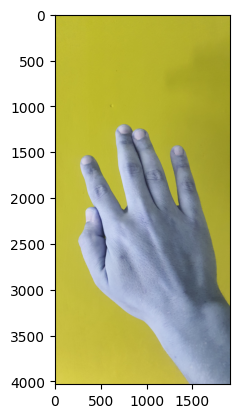

In [46]:
plt.figure(), plt.imshow(train_images[0][0])

(<Figure size 640x480 with 1 Axes>,
 <matplotlib.image.AxesImage at 0x7ae6f5fc2ba0>)

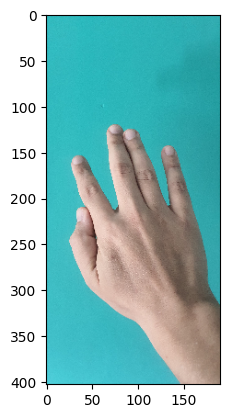

In [47]:
for i, cls in enumerate(train_images):
  for j, image in enumerate(cls):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    width, height, channel = np.shape(image)
    image = cv2.resize(image, (height//10, width//10))
    train_images[i][j] = image
plt.figure(), plt.imshow(train_images[0][0])


(<Figure size 640x480 with 1 Axes>,
 <matplotlib.image.AxesImage at 0x7ae6ede91640>)

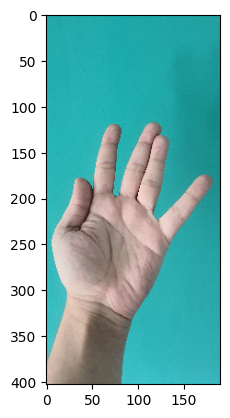

In [48]:
for i, cls in enumerate(test_images):
  for j, image in enumerate(cls):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    width, height, channel = np.shape(image)
    image = cv2.resize(image, (height//10, width//10))
    test_images[i][j] = image
plt.figure(), plt.imshow(test_images[0][0])

In [49]:
def detectie_culoare_piele(img):
    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

    C1 = np.zeros((img.shape[0], img.shape[1]))
    C2 = np.zeros((img.shape[0], img.shape[1]))
    C3 = np.zeros((img.shape[0], img.shape[1]))
    C4 = np.zeros((img.shape[0], img.shape[1]))
    C5 = np.zeros((img.shape[0], img.shape[1]))
    C6 = np.zeros((img.shape[0], img.shape[1]))
    C7 = np.zeros((img.shape[0], img.shape[1]))
    rez = np.zeros((img.shape[0], img.shape[1]))

    C1[np.logical_and(R > 95, G > 40, B > 20)] = 1
    C2[(np.maximum(np.maximum(R, G), B) - np.minimum(np.minimum(R, G), B)) > 15] = 1
    C3[np.absolute(R - G) > 15] = 1
    C4[np.logical_and(R > G, R > B)] = 1

    C5[np.logical_and(R > 220, G > 210, B > 170)] = 1
    C6[np.absolute(R - G) <= 15] = 1
    C7[np.logical_and(R > B, G > B)] = 1

    caz1 = np.logical_and(np.logical_and(C1 == 1, C2 == 1, C3 == 1), C4 == 1)
    caz2 = np.logical_and(C5 == 1, C6 == 1, C7 == 1)

    rez[np.logical_or(caz1 == 1, caz2 == 1)] = 1

    return rez

In [50]:
train_image_mask = []
for i, cls in enumerate(train_images):
  tmp = []
  for j, image in enumerate(cls):
    tmp.append(detectie_culoare_piele(image))
  train_image_mask.append(tmp)

(<Figure size 640x480 with 1 Axes>,
 <matplotlib.image.AxesImage at 0x7ae6ee5ce600>)

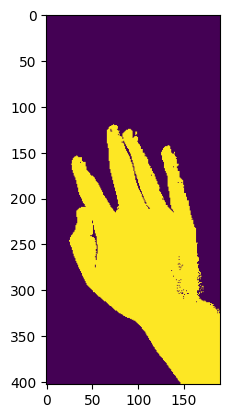

In [51]:
plt.figure(), plt.imshow(train_image_mask[0][0])

In [52]:
test_image_mask = []
for i, cls in enumerate(test_images):
  tmp = []
  for j, image in enumerate(cls):
    tmp.append(detectie_culoare_piele(image))
  test_image_mask.append(tmp)

(<Figure size 640x480 with 1 Axes>,
 <matplotlib.image.AxesImage at 0x7ae6edd8f2f0>)

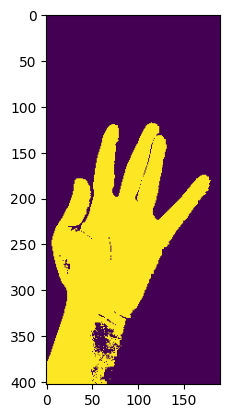

In [53]:
plt.figure(), plt.imshow(test_image_mask[0][0])

In [54]:
def get_largest_contour_bbox(mask):
    # Convert the mask to 8-bit single-channel image, if not already
    mask_8bit = mask.astype(np.uint8)

    # Find contours
    contours, _ = cv2.findContours(mask_8bit, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    if not contours:
        return None # Return None if no contours found

    # Find the largest contour
    largest_contour = max(contours, key=cv2.contourArea)

    # Get the bounding box of the largest contour
    x, y, w, h = cv2.boundingRect(largest_contour)
    return (x, y, w, h)

In [55]:
train_bboxes = []
for i, cls_masks in enumerate(train_image_mask):
    tmp_cls_bboxes = []
    for j, mask in enumerate(cls_masks):
        bbox = get_largest_contour_bbox(mask)
        tmp_cls_bboxes.append(bbox)
    train_bboxes.append(tmp_cls_bboxes)

print(f"Example train bbox for class 0, image 0: {train_bboxes[0][0]}")

Example train bbox for class 0, image 0: (25, 120, 165, 283)


In [56]:
test_bboxes = []
for i, cls_masks in enumerate(test_image_mask):
    tmp_cls_bboxes = []
    for j, mask in enumerate(cls_masks):
        bbox = get_largest_contour_bbox(mask)
        tmp_cls_bboxes.append(bbox)
    test_bboxes.append(tmp_cls_bboxes)

print(f"Example test bbox for class 0, image 0: {test_bboxes[0][0]}")

Example test bbox for class 0, image 0: (0, 118, 179, 285)


Text(0.5, 1.0, 'Train Image with Largest Contour Bounding Box')

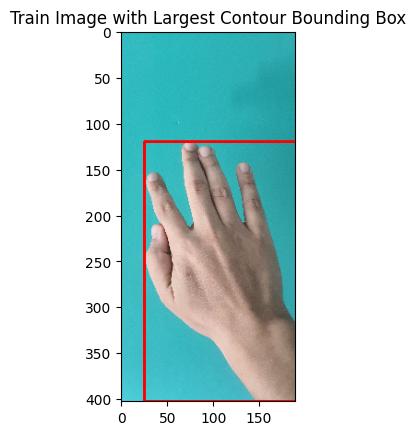

In [57]:
# Optional: Visualize an image with its extracted bounding box
example_train_image = train_images[0][0].copy() # Get original image
example_train_bbox = train_bboxes[0][0]

if example_train_bbox:
    x, y, w, h = example_train_bbox
    cv2.rectangle(example_train_image, (x, y), (x + w, y + h), (255, 0, 0), 2) # Draw red rectangle

plt.figure(), plt.imshow(example_train_image)
plt.title('Train Image with Largest Contour Bounding Box')

In [58]:
def crop_and_mask_image(image, bbox, mask):
    if bbox is None:
        # If no bounding box is found, return a black image of the same shape
        return np.zeros_like(image, dtype=image.dtype)

    x, y, w, h = bbox

    # Crop the image
    cropped_image = image[y:y+h, x:x+w].copy()

    # Crop the corresponding mask
    cropped_mask = mask[y:y+h, x:x+w].copy()

    # Convert the mask to 8-bit single channel for OpenCV operations
    # Ensure it's explicitly 0 or 255 for cv2.bitwise_and
    cropped_mask_8bit = (cropped_mask * 255).astype(np.uint8)

    # Apply the mask using cv2.bitwise_and
    # This function automatically handles the channel broadcasting if the mask is 1-channel
    final_image = cv2.bitwise_and(cropped_image, cropped_image, mask=cropped_mask_8bit)

    return final_image

In [59]:
# Apply the crop and mask operation to training images
train_cropped_masked_images = []
for cls_idx, cls_images in enumerate(train_images):
    tmp_cls_cropped_masked = []
    for img_idx, image in enumerate(cls_images):
        bbox = train_bboxes[cls_idx][img_idx]
        mask = train_image_mask[cls_idx][img_idx]
        cropped_masked_img = crop_and_mask_image(image, bbox, mask)
        tmp_cls_cropped_masked.append(cropped_masked_img)
    train_cropped_masked_images.append(tmp_cls_cropped_masked)

print(f"Shape of first cropped and masked training image: {train_cropped_masked_images[0][0].shape}")

Shape of first cropped and masked training image: (283, 165, 3)


In [60]:
# Apply the crop and mask operation to testing images
test_cropped_masked_images = []
for cls_idx, cls_images in enumerate(test_images):
    tmp_cls_cropped_masked = []
    for img_idx, image in enumerate(cls_images):
        bbox = test_bboxes[cls_idx][img_idx]
        mask = test_image_mask[cls_idx][img_idx]
        cropped_masked_img = crop_and_mask_image(image, bbox, mask)
        tmp_cls_cropped_masked.append(cropped_masked_img)
    test_cropped_masked_images.append(tmp_cls_cropped_masked)

print(f"Shape of first cropped and masked testing image: {test_cropped_masked_images[0][0].shape}")

Shape of first cropped and masked testing image: (285, 179, 3)


Text(0.5, 1.0, 'Example of Cropped and Masked Test Image')

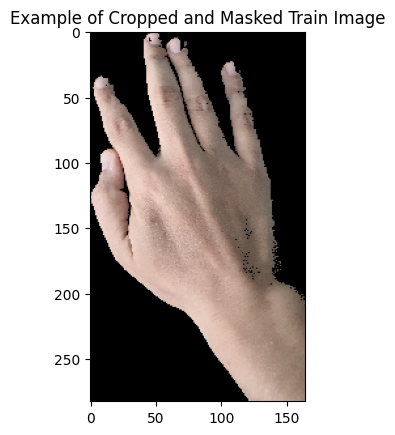

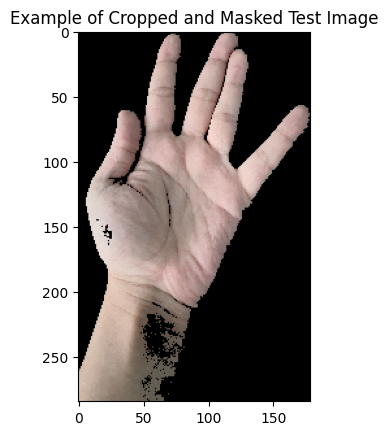

In [61]:
# Visualize an example of a cropped and masked training image
plt.figure(), plt.imshow(train_cropped_masked_images[0][0])
plt.title('Example of Cropped and Masked Train Image')

# Visualize an example of a cropped and masked testing image
plt.figure(), plt.imshow(test_cropped_masked_images[0][0])
plt.title('Example of Cropped and Masked Test Image')

In [62]:
winSize = (64,64)
blockSize = (16,16)
blockStride = (8,8)
cellSize = (8,8)
nbins = 9
rndpat = 0
derivAperture = 1
winSigma = 4.
histogramNormType = 0
L2HysThreshold = 2.0000000000000001e-01
gammaCorrection = 0
nlevels = 64

hog = cv2.HOGDescriptor(winSize,blockSize,blockStride,cellSize,nbins,derivAperture,winSigma,
                        histogramNormType,L2HysThreshold,gammaCorrection,nlevels)


In [63]:
train_hog_features = []
train_labels = []
winSize = (64,128)
for cls_idx, cls_images in enumerate(train_cropped_masked_images):
    for image in cls_images:
        # HOG usually works on grayscale images
        if len(image.shape) == 3 and image.shape[2] == 3:
            gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray_image = image # Assume it's already grayscale or single channel

        # Resize image to winSize if necessary
        if gray_image.shape[0] != winSize[1] or gray_image.shape[1] != winSize[0]:
            resized_image = cv2.resize(gray_image, winSize, interpolation=cv2.INTER_AREA)
        else:
            resized_image = gray_image

        # Compute HOG features
        # The descriptor will be a 1D numpy array
        features = hog.compute(resized_image)
        train_hog_features.append(features.flatten())
        train_labels.append(cls_idx)

train_hog_features = np.array(train_hog_features)
train_labels = np.array(train_labels)

print(f"Shape of train HOG features: {train_hog_features.shape}")
print(f"Shape of train labels: {train_labels.shape}")

Shape of train HOG features: (28, 15876)
Shape of train labels: (28,)


In [64]:
test_hog_features = []
test_labels = []

for cls_idx, cls_images in enumerate(test_cropped_masked_images):
    for image in cls_images:
        # HOG usually works on grayscale images
        if len(image.shape) == 3 and image.shape[2] == 3:
            gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray_image = image # Assume it's already grayscale or single channel

        # Resize image to winSize if necessary
        if gray_image.shape[0] != winSize[1] or gray_image.shape[1] != winSize[0]:
            resized_image = cv2.resize(gray_image, winSize, interpolation=cv2.INTER_AREA)
        else:
            resized_image = gray_image

        # Compute HOG features
        features = hog.compute(resized_image)
        test_hog_features.append(features.flatten())
        test_labels.append(cls_idx)

test_hog_features = np.array(test_hog_features)
test_labels = np.array(test_labels)

print(f"Shape of test HOG features: {test_hog_features.shape}")
print(f"Shape of test labels: {test_labels.shape}")

Shape of test HOG features: (12, 15876)
Shape of test labels: (12,)


In [65]:
from sklearn.svm import SVC

# Initialize SVM with a 2-degree polynomial kernel
svm_classifier = SVC(kernel='poly', degree=2, random_state=42)

# Train the SVM classifier
svm_classifier.fit(train_hog_features, train_labels)

print("SVM classifier trained successfully!")

SVM classifier trained successfully!


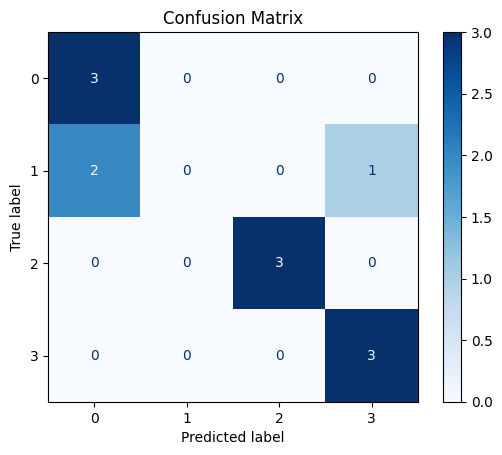

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Make predictions on the test set
test_predictions = svm_classifier.predict(test_hog_features)

# Generate the confusion matrix
cm = confusion_matrix(test_labels, test_predictions)

# Get unique labels from the training set to ensure all classes are represented in display_labels
unique_labels = np.unique(train_labels)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[str(i) for i in unique_labels])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()